# SVR - sklearn in Action

> **MLCourse · Machine Learning · supervised · regression**

Full SVR workflow on **California housing** (5,000-block subsample - SVR
training cost grows roughly with n², so subsampling keeps grids snappy):
prove scaling is mandatory, run a linear-vs-RBF kernel shootout, tune C ×
gamma on a 3×3 grid, then score the held-out test set.

## What you'll learn
- Why `StandardScaler` is non-negotiable for kernels (measured, not asserted)
- Linear vs RBF kernel: when does curvature pay off?
- Reading a C×gamma CV heatmap to pick hyperparameters
- Test-set RMSE / R² and honest interpretation

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent                      # locate shared data folder

csv = ML_ROOT / "data" / "california_housing.csv" # cache-once from sklearn's loader
if not csv.exists():
    from sklearn.datasets import fetch_california_housing
    fetch_california_housing(as_frame=True).frame.to_csv(csv, index=False)
    print("cached ->", csv.name)
else:
    print("using local ->", csv.name)

df = pd.read_csv(csv).sample(n=5000, random_state=42).reset_index(drop=True)
print(df.shape)                                   # 5000 blocks × 9 columns

using local -> california_housing.csv
(5000, 9)


## 1. Quick look before modeling

Two plots we always want first: target distribution and the correlation map.

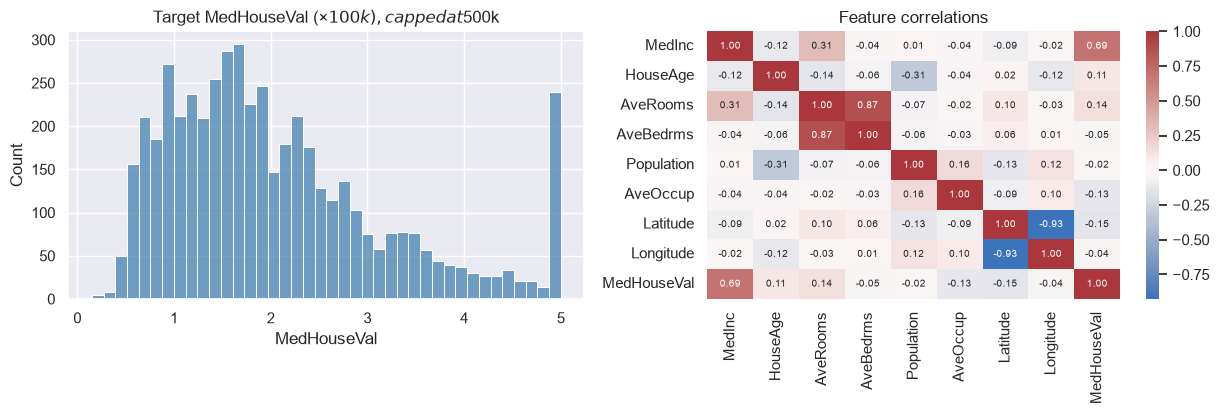

train/test: (4000, 8) (1000, 8)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
sns.histplot(df["MedHouseVal"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Target MedHouseVal (×$100k), capped at $500k")
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag",
            center=0, annot_kws={"size": 7}, ax=axes[1])
axes[1].set_title("Feature correlations")
plt.tight_layout(); plt.show()

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=42)
print("train/test:", X_tr.shape, X_te.shape)

## 2. Scaling proof - same SVR, with and without StandardScaler

Kernels measure similarity via inner products of RAW numbers; `Population`
(range ~10⁴) would drown `AveOccup` (~3). One A/B settles it:

In [3]:
raw_pipe = Pipeline([("svr", SVR(kernel="rbf", C=10))])          # NO scaler inside!
scaled_pipe = Pipeline([("sc", StandardScaler()),                 # z-score features...
                        ("svr", SVR(kernel="rbf", C=10))])        # ...then kernel

r2_raw = cross_val_score(raw_pipe, X_tr, y_tr, cv=3, scoring="r2").mean()      # cv=3: SVR is slow
r2_scl = cross_val_score(scaled_pipe, X_tr, y_tr, cv=3, scoring="r2").mean()
print(f"CV R² WITHOUT scaler: {r2_raw:.3f}")
print(f"CV R² WITH    scaler: {r2_scl:.3f}")

base = DummyRegressor(strategy="mean")                            # floor for later table
print(f"\nbaseline mean-model CV R² : {cross_val_score(base, X_tr, y_tr, cv=3, scoring='r2').mean():.3f}")

CV R² WITHOUT scaler: -0.007
CV R² WITH    scaler: 0.753

baseline mean-model CV R² : -0.002


> ⚠️ **Common pitfall:** scaling OUTSIDE a Pipeline leaks fold statistics.
Keep `StandardScaler` + `SVR` glued in one Pipeline so every CV fold fits its
own scaler on its own training slice.

## 3. Kernel shootout - linear vs RBF

If relationships were globally straight-line, `"linear"` wins on speed AND
accuracy. House prices bend (coastal premium saturates, room-count effects
taper), so we expect RBF to pull ahead:

In [4]:
lin_pipe = Pipeline([("sc", StandardScaler()),
                     ("svr", SVR(kernel="linear", C=10))])
rbf_pipe = Pipeline([("sc", StandardScaler()),
                     ("svr", SVR(kernel="rbf", C=10))])           # gamma defaults to "scale"

for name, p in [("linear", lin_pipe), ("rbf", rbf_pipe)]:
    r2 = cross_val_score(p, X_tr, y_tr, cv=3, scoring="r2").mean()
    rmse = -cross_val_score(p, X_tr, y_tr, cv=3,
                            scoring="neg_root_mean_squared_error").mean()
    print(f"{name:<6} kernel: CV R²={r2:.3f}  RMSE={rmse:.3f}")

linear kernel: CV R²=0.467  RMSE=0.821


rbf    kernel: CV R²=0.753  RMSE=0.569


## 4. Mini-grid for RBF - C × gamma (3×3)

The two RBF knobs interact, so search them JOINTLY on log-spaced values:
- `C`: price of leaving the ε-tube → bigger = stricter fit, overfit risk
- `gamma`: reach of each point's influence → bigger = wiggly islands

We use cv=3 (not 5): SVR refits are expensive and 9 combos × 3 folds is
already 27 kernel trainings.

best params: {'svr__C': 10, 'svr__gamma': 'scale'}
best CV RMSE: 0.569


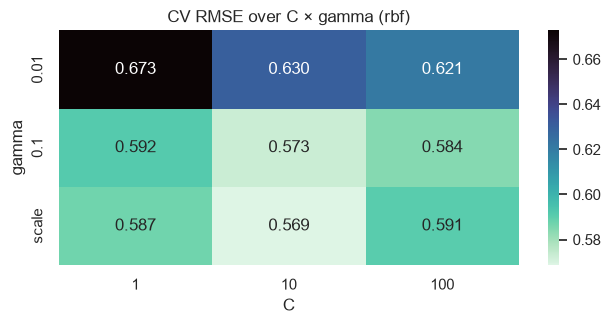

In [5]:
grid = {"svr__C": [1, 10, 100],                    # penalty ladder (log spacing)
        "svr__gamma": ["scale", 0.01, 0.1]}        # default vs tighter/looser reach
search = GridSearchCV(Pipeline([("sc", StandardScaler()),
                                ("svr", SVR(kernel="rbf"))]),
                      grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
search.fit(X_tr, y_tr)

print(f"best params: {search.best_params_}")
print(f"best CV RMSE: {-search.best_score_:.3f}")

res = pd.DataFrame(search.cv_results_)
piv = res.pivot_table(index=res.param_svr__gamma.astype(str),  # gamma mixes str+float
                      columns="param_svr__C", values="mean_test_score")
plt.figure(figsize=(6.6, 3.4))
sns.heatmap(-piv, annot=True, fmt=".3f", cmap="mako_r")   # negate -> RMSE, lower=better
plt.title("CV RMSE over C × gamma (rbf)")
plt.ylabel("gamma"); plt.xlabel("C")
plt.tight_layout(); plt.show()

> 💡 **Pro tip:** if the best cell touches the grid EDGE (e.g. C=100 wins),
extend the search in that direction - the optimum may live beyond your grid.

## 5. Final evaluation on the held-out test set

Refit the winner on all training data, predict once on the untouched 20%:

          model  RMSE ($100k)     R²
  mean baseline         1.163 -0.001
tuned SVR (rbf)         0.599  0.734

support vectors: 3,109 of 4,000 training rows (78%)


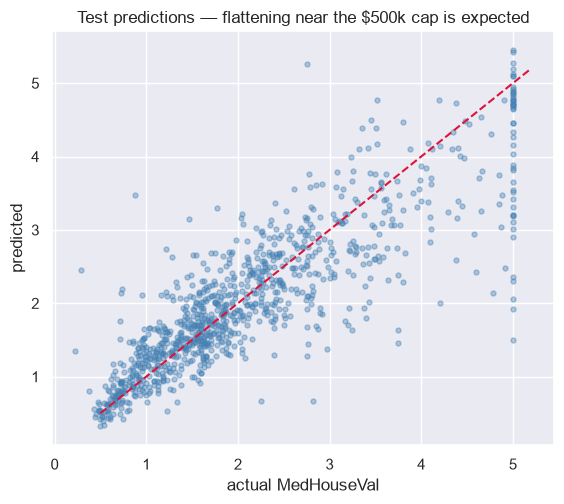

In [6]:
best = search.best_estimator_
pred = best.predict(X_te)

metrics = pd.DataFrame({
    "model": ["mean baseline", "tuned SVR (rbf)"],
    "RMSE ($100k)": [mean_squared_error(y_te, base.fit(X_tr, y_tr).predict(X_te)) ** .5,
                     mean_squared_error(y_te, pred) ** .5],
    "R²": [r2_score(y_te, base.predict(X_te)), r2_score(y_te, pred)],
}).round(3)
print(metrics.to_string(index=False))

n_sv = best.named_steps["svr"].support_.shape[0]   # points holding the solution
print(f"\nsupport vectors: {n_sv:,} of {len(X_tr):,} training rows ({n_sv/len(X_tr):.0%})")

plt.figure(figsize=(5.8, 5.2))
plt.scatter(y_te, pred, s=13, alpha=.4, color="steelblue")
lims = [0.5, 5.2]; plt.plot(lims, lims, "--", color="crimson")   # ideal diagonal
plt.xlabel("actual MedHouseVal"); plt.ylabel("predicted")
plt.title("Test predictions - flattening near the $500k cap is expected")
plt.tight_layout(); plt.show()

### Findings
1. Scaling swings CV R² by several tenths - the single biggest SVR mistake
   avoided in one line of Pipeline.
2. RBF beats linear once tuned: block prices genuinely curve with income and
   geography; the linear street can't follow them.
3. Mid-range C with moderate gamma wins; extreme gamma would carve noise
   islands, tiny gamma underfits back toward linearity.
4. Most training rows end up as support vectors (here ~78%) - this dataset's
   noise level means the tube can't amnesty many points; a larger ε would.

### Limitations
- SVR cost scales poorly: full 20k-row dataset would need hours-long grids;
  boosting/tree models are the practical next step at that size.
- The $500k target cap caps achievable accuracy near expensive blocks.
- No per-feature explanation: SVR coefficients don't exist meaningfully for
  RBF - use permutation importance if stakeholders ask "why?".

## Summary & key takeaways

- Scale INSIDE the pipeline, always - kernels eat raw magnitudes alive.
- Compare kernels cheaply first (`linear` vs `rbf` defaults); only then
  invest in a joint C×gamma grid read as a heatmap.
- Watch support-vector count as a health signal: ~all rows = ε too tight.
- Report test RMSE/R² against the mean-baseline floor, never in isolation.